# ConsentGuard: Full Data and Model Forensic Audit

This notebook audits the complete data path used by the completed Mask R-CNN v3 experiment. It scans all 1,195 selected images and 5,084 polygon instances, summarizes all 8,473 source image/annotation geometry records, evaluates the final checkpoint on the full training split, and compares it with the completed validation and eight-image overfit controls.

The test split is checked structurally but is not used for model evaluation, threshold selection, or qualitative model inspection.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'src'))

from scripts.full_data_model_audit import run_audit

AUDIT_DIR = ROOT / 'reports' / 'full_audit'
summary = run_audit(AUDIT_DIR, force_model_eval=False)
print(f'Audit artifacts: {AUDIT_DIR}')

ConsentGuard full audit output: C:\consentGuard\reports\full_audit


[data] using cached per-image and per-instance profiles


[model] using cached full-train evaluation: C:\consentGuard\reports\full_audit\model_train_evaluation.json


{
  "verdict": {
    "primary_blocker": "invalid cross-dataset identity join: Visual Redactions masks were paired with different VISPR pixels",
    "secondary_blocker": "after repairing pixels, rare-class scarcity and a single-model modality mismatch remain",
    "do_not_do": "Do not start another Mask R-CNN, Mask2Former, or any other model on the current records.",
    "recommended_next_action": "Download the separate official Visual Redactions image archives, require pixel-identity evidence, rebuild records, and manually approve a stratified benchmark before retraining.",
    "checkpoint_diagnosis": "severe full-training-set underfit or inconsistent/noisy supervision"
  },
  "model": {
    "full_train_mask_map": 0.018694000621739777,
    "validation_mask_map": 0.00025558234887933934,
    "eight_image_overfit_best_mask_map": 0.3029349363507779
  }
}


Audit artifacts: C:\consentGuard\reports\full_audit


## Executive finding

The current training set is invalid. Visual Redactions masks were joined to VISPR pixels using similar-looking `2017_xxxxxxxx` identifiers, but the identifier namespaces do not preserve image identity across these releases. The correct Visual Redactions image archives are separate downloads. A model change cannot repair masks that supervise unrelated pixels.

In [2]:
verdict = summary['verdict']
model = summary['model']
processed = summary['processed_data']
overview = pd.DataFrame([
    ['Primary blocker', verdict['primary_blocker']],
    ['Correct Visual Redactions images present', summary['download_integrity']['visual_redactions_correct_image_archives_downloaded']],
    ['Source pairs eligible by aspect ratio', f"{summary['geometry']['aligned_resize']:,} / {summary['scope']['source_manifest_records']:,} ({summary['geometry']['eligible_fraction']:.1%})"],
    ['Selected records decoded', f"{summary['scope']['selected_records_scanned']:,}; failures={len(json.load(open(AUDIT_DIR / 'decode_failures.json')))}"],
    ['Clearly mismatched in stratified review', f"{processed['manual_stratified_review']['result_counts'].get('clearly_mismatched', 0)} / {processed['manual_stratified_review']['images_reviewed']}"],
    ['Full-train mask mAP', f"{model['full_train_mask_map']:.6f}"],
    ['Validation mask mAP', f"{model['validation_mask_map']:.6f}"],
    ['Eight-image overfit best mask mAP', f"{model['eight_image_overfit_best_mask_map']:.3f}"],
], columns=['Question', 'Evidence'])
display(overview.style.hide(axis='index'))

Question,Evidence
Primary blocker,invalid cross-dataset identity join: Visual Redactions masks were paired with different VISPR pixels
Correct Visual Redactions images present,False
Source pairs eligible by aspect ratio,"1,433 / 8,473 (16.9%)"
Selected records decoded,"1,195; failures=0"
Clearly mismatched in stratified review,14 / 18
Full-train mask mAP,0.018694
Validation mask mAP,0.000256
Eight-image overfit best mask mAP,0.303


## Root-cause evidence: same ID, different content

The Visual Redactions weak annotations describe what the mask source image contained. The local pixels used during training come from the VISPR archive. These examples prove that an ID match was not an image-identity match.

In [3]:
identity_evidence = pd.read_csv(AUDIT_DIR / 'root_cause_identity_evidence.csv', dtype={'image_id': str})
display(identity_evidence.style.hide(axis='index'))
archives = summary['download_integrity']['visual_redactions_required_image_archives']
archive_table = pd.DataFrame([
    [split, entry['bytes'], entry['bytes'] / 1024**3, entry['url']]
    for split, entry in archives.items()
], columns=['Split', 'Bytes', 'GiB', 'Official URL'])
display(archive_table.style.format({'Bytes': '{:,.0f}', 'GiB': '{:.3f}'}).hide(axis='index'))

image_id,visual_redactions_weak_metadata,current_vispr_pixels,conclusion
2017_43553890,water; marine mammal; dolphin,woman reading outdoors,Same ID refers to different image content.
2017_71785925,identity document; student ID card; OCR text,banquet or wedding room,Same ID refers to different image content.
2017_57329651,technology; desk; health care; clinic,vintage car exhibition,Same ID refers to different image content.
2017_75004412,paper application form; OCR text,stage performance,Same ID refers to different image content.
2017_37580933,civil registry document; OCR text,building and streetscape,Same ID refers to different image content.


Split,Bytes,GiB,Official URL
train2017,"7,816,171,895",7.279,https://datasets.d2.mpi-inf.mpg.de/orekondy18cvpr/v1/images/train2017.tar.gz
val2017,"3,158,549,744",2.942,https://datasets.d2.mpi-inf.mpg.de/orekondy18cvpr/v1/images/val2017.tar.gz
test2017,"5,633,037,591",5.246,https://datasets.d2.mpi-inf.mpg.de/orekondy18cvpr/v1/images/test2017.tar.gz


## Data inventory, geometry, and class support

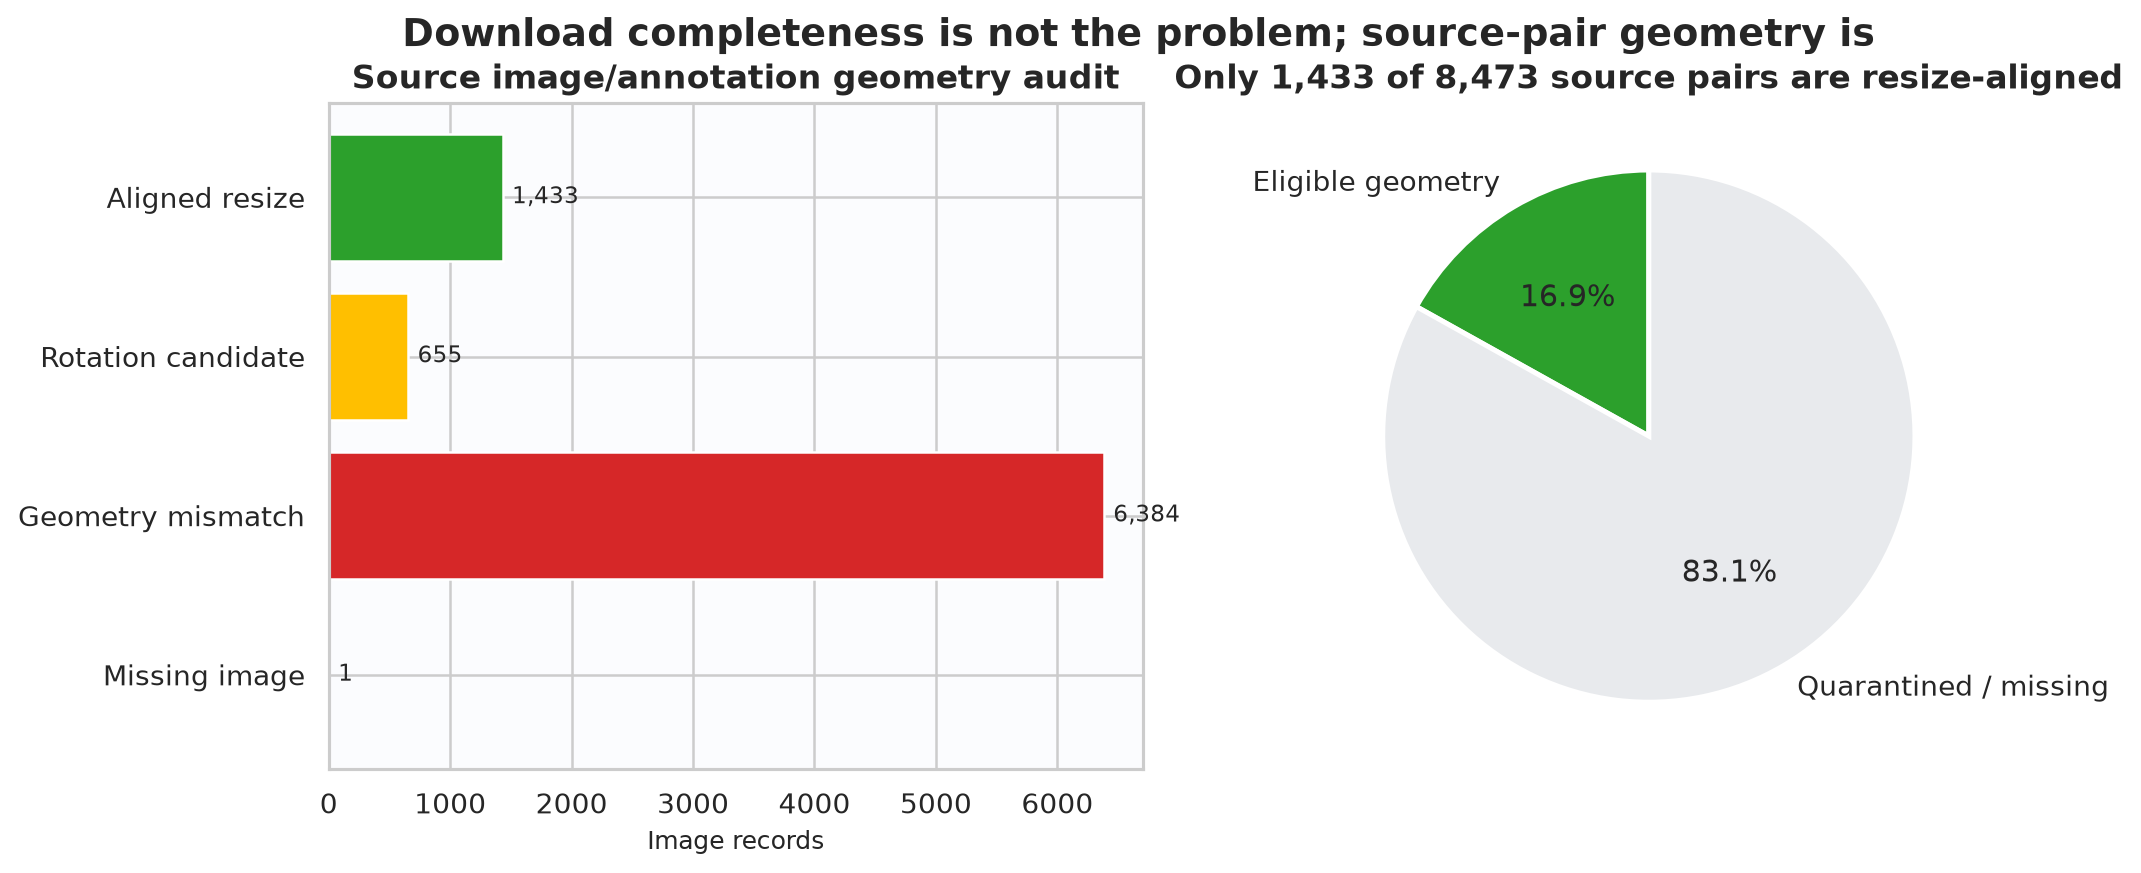

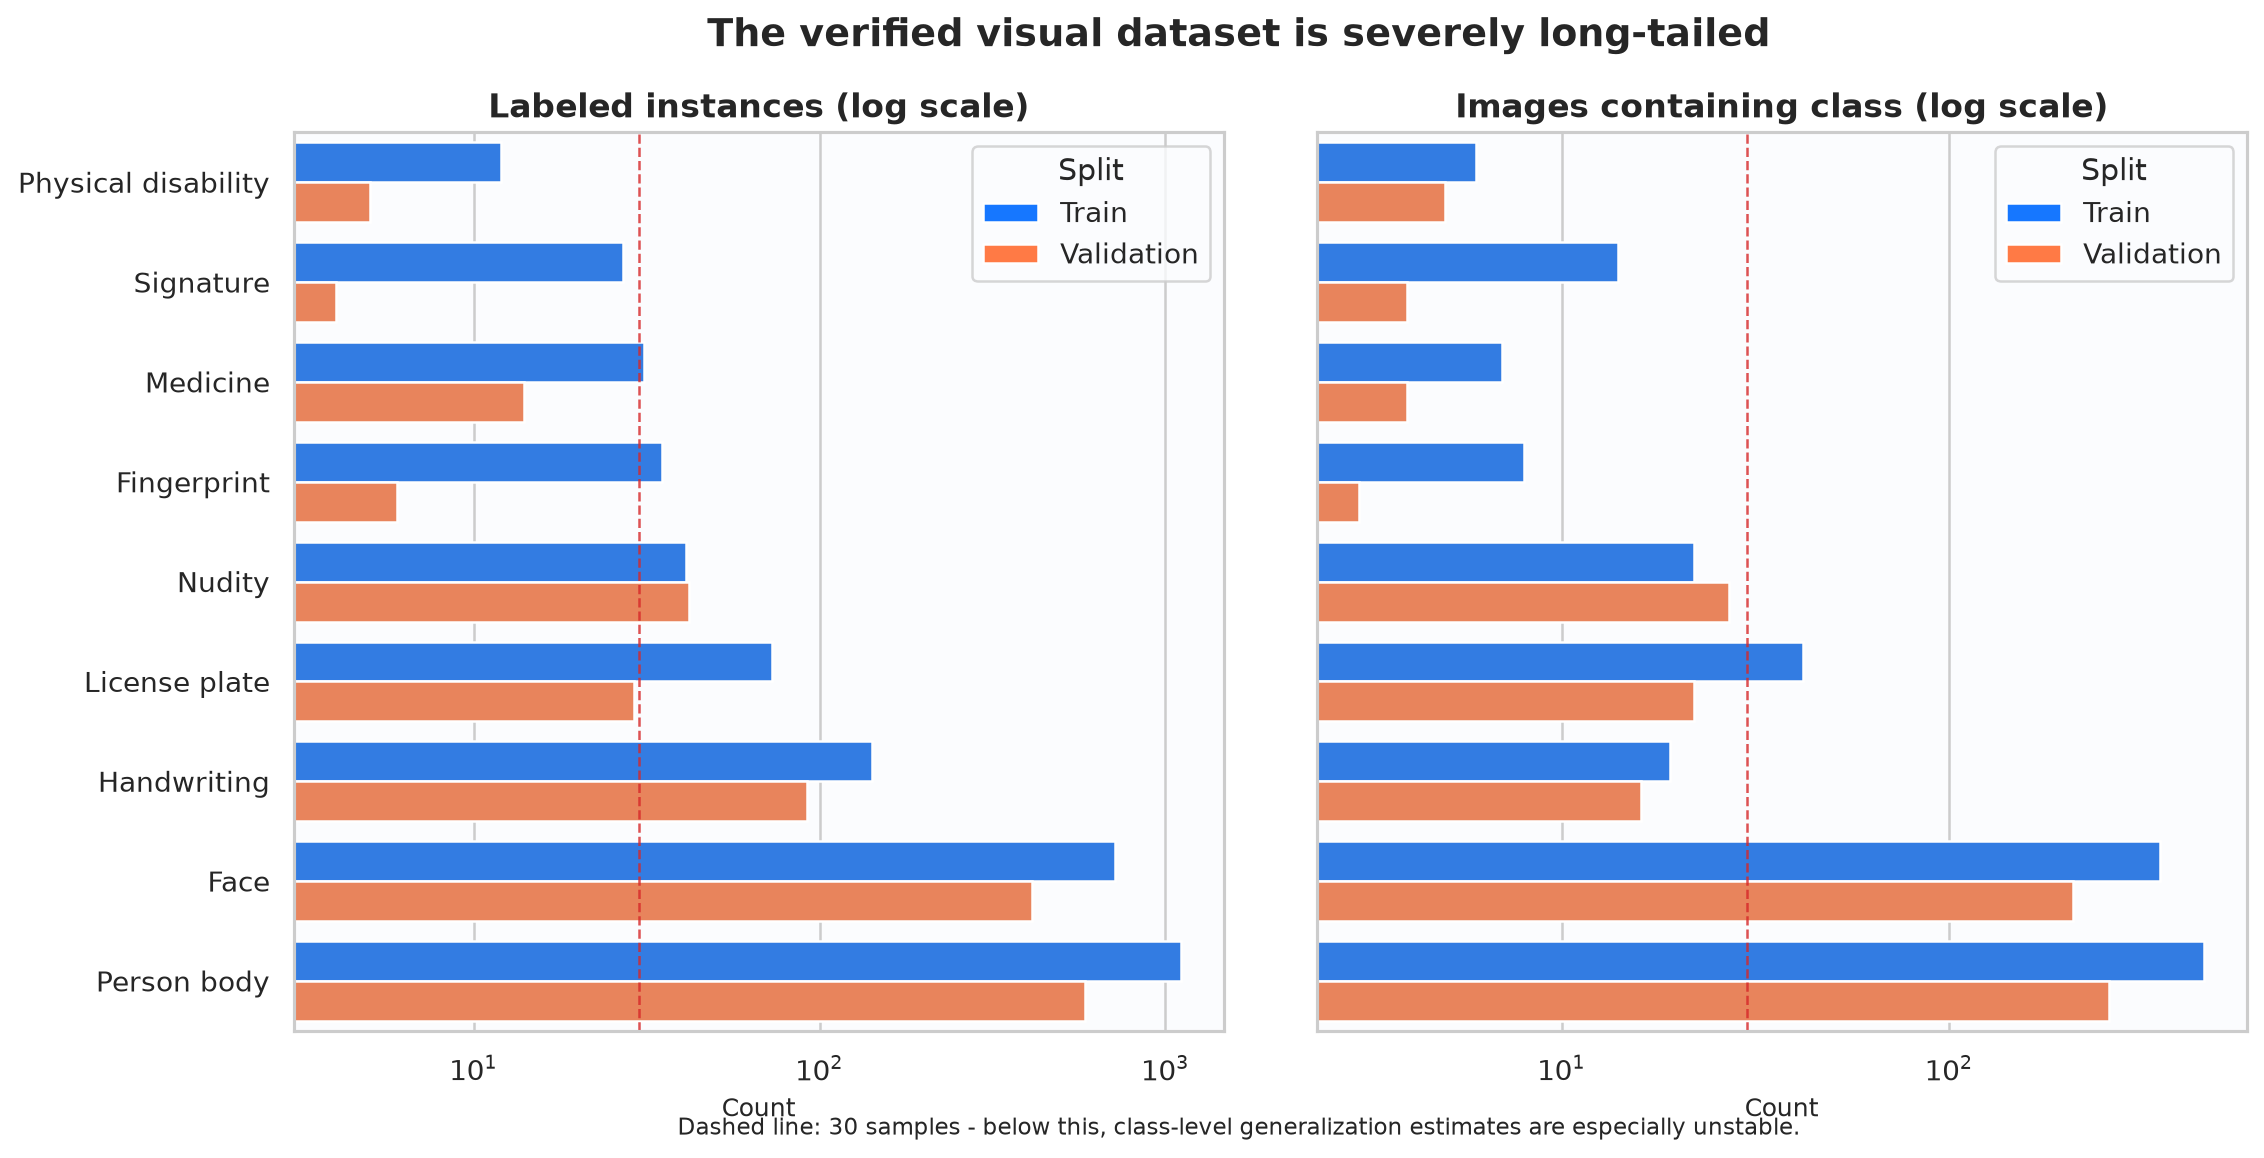

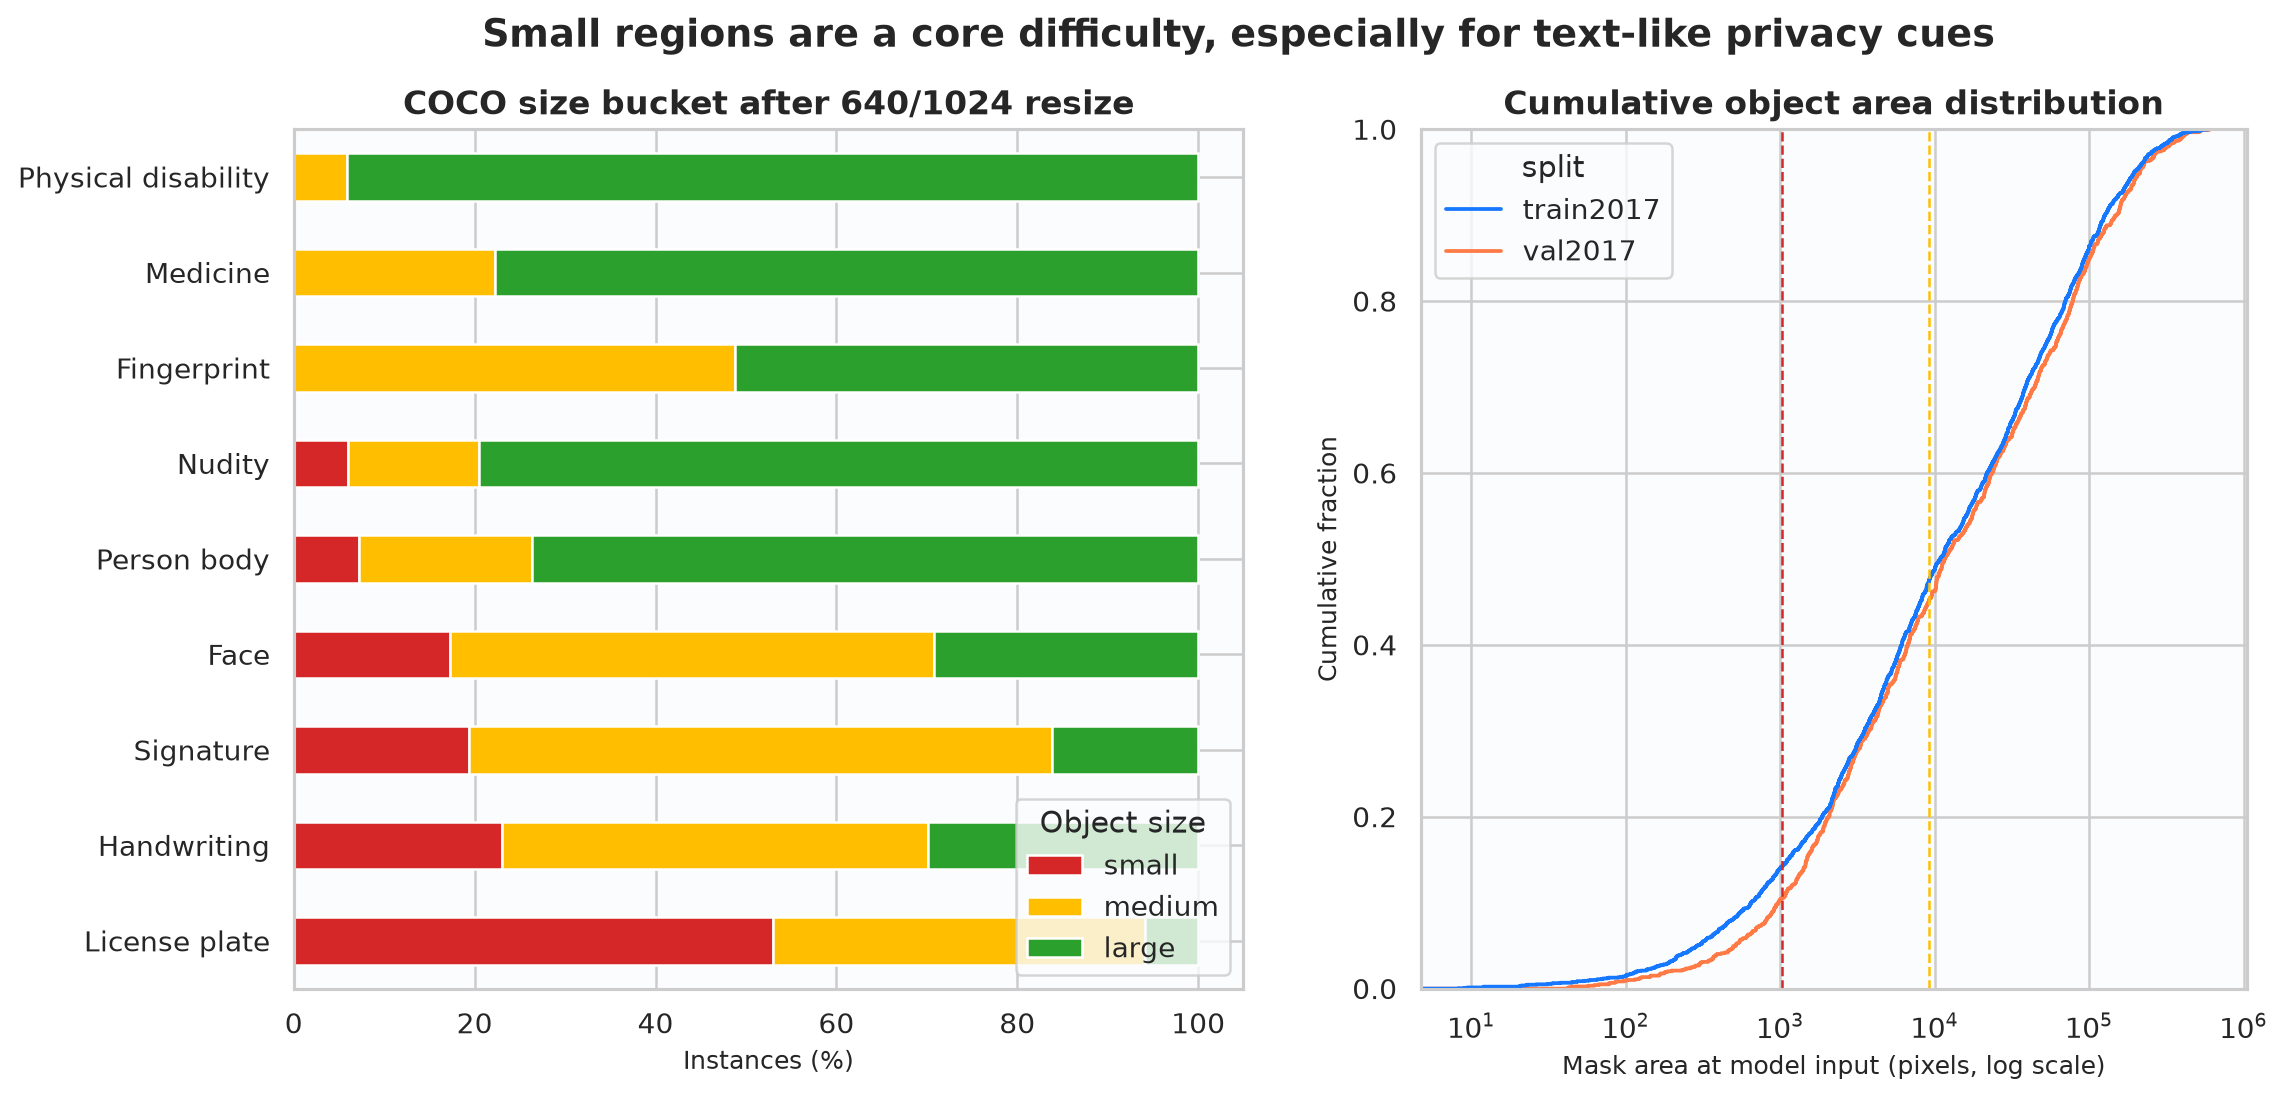

In [4]:
for name in ['01_download_and_geometry.png', '02_class_support.png', '03_object_sizes.png']:
    display(Image(filename=str(AUDIT_DIR / name), width=1100))

## Pixel quality, annotation proxies, and co-occurrence

Boundary edge support is only a prioritization proxy: valid soft/occluded boundaries can score poorly, and incorrect masks can intersect edges by chance. The manual overlays below are the deciding evidence.

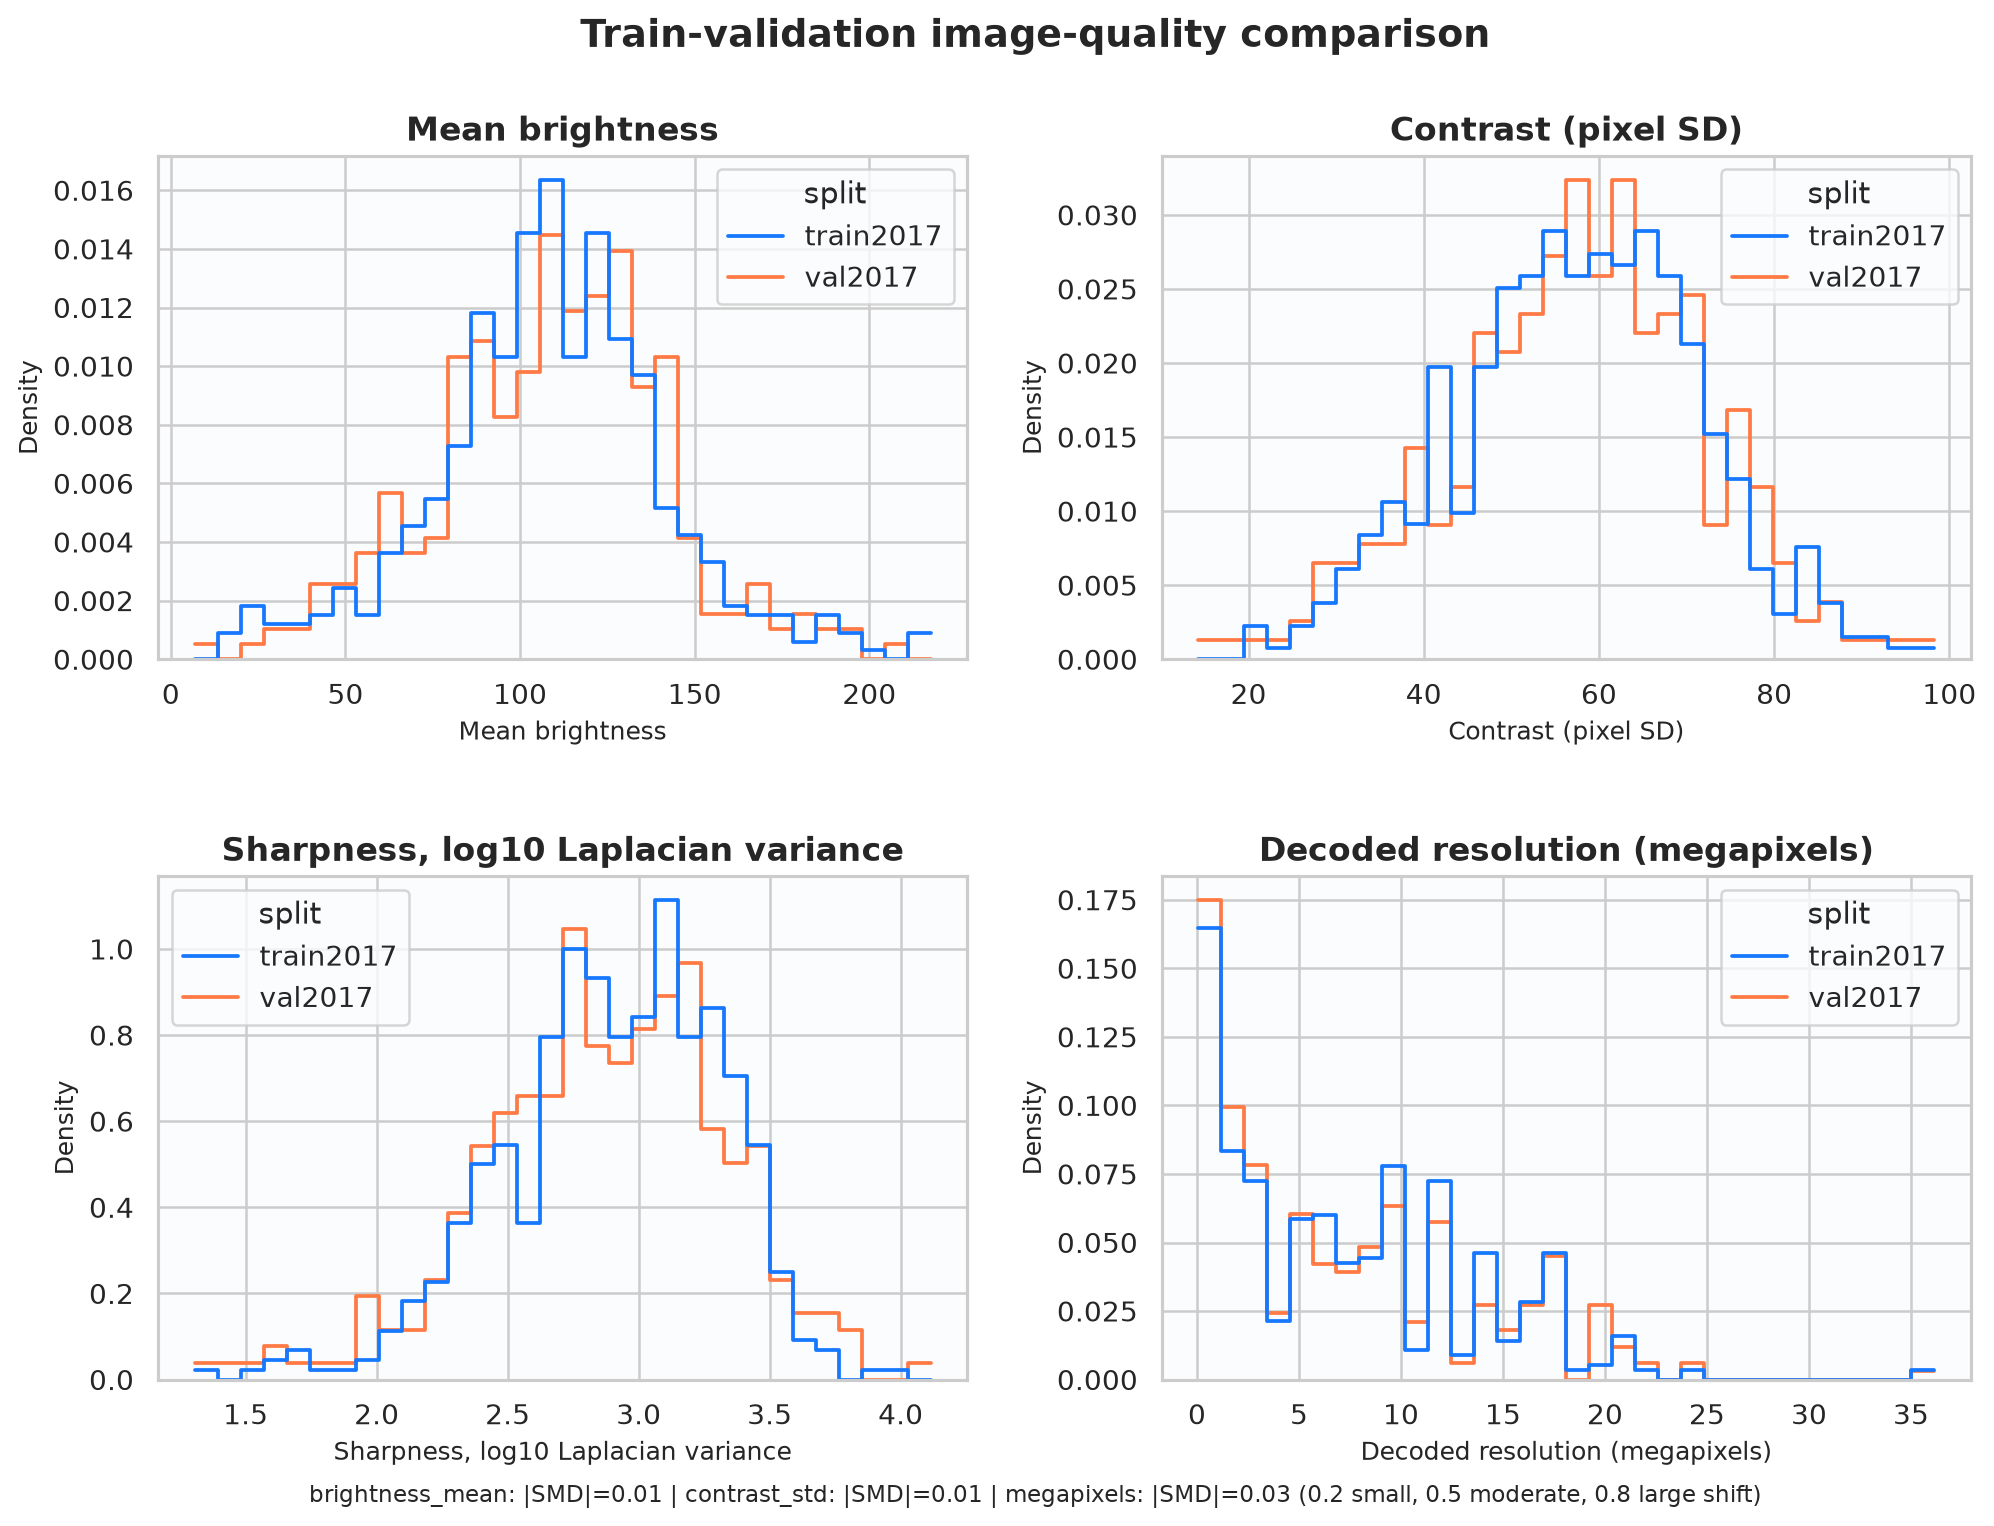

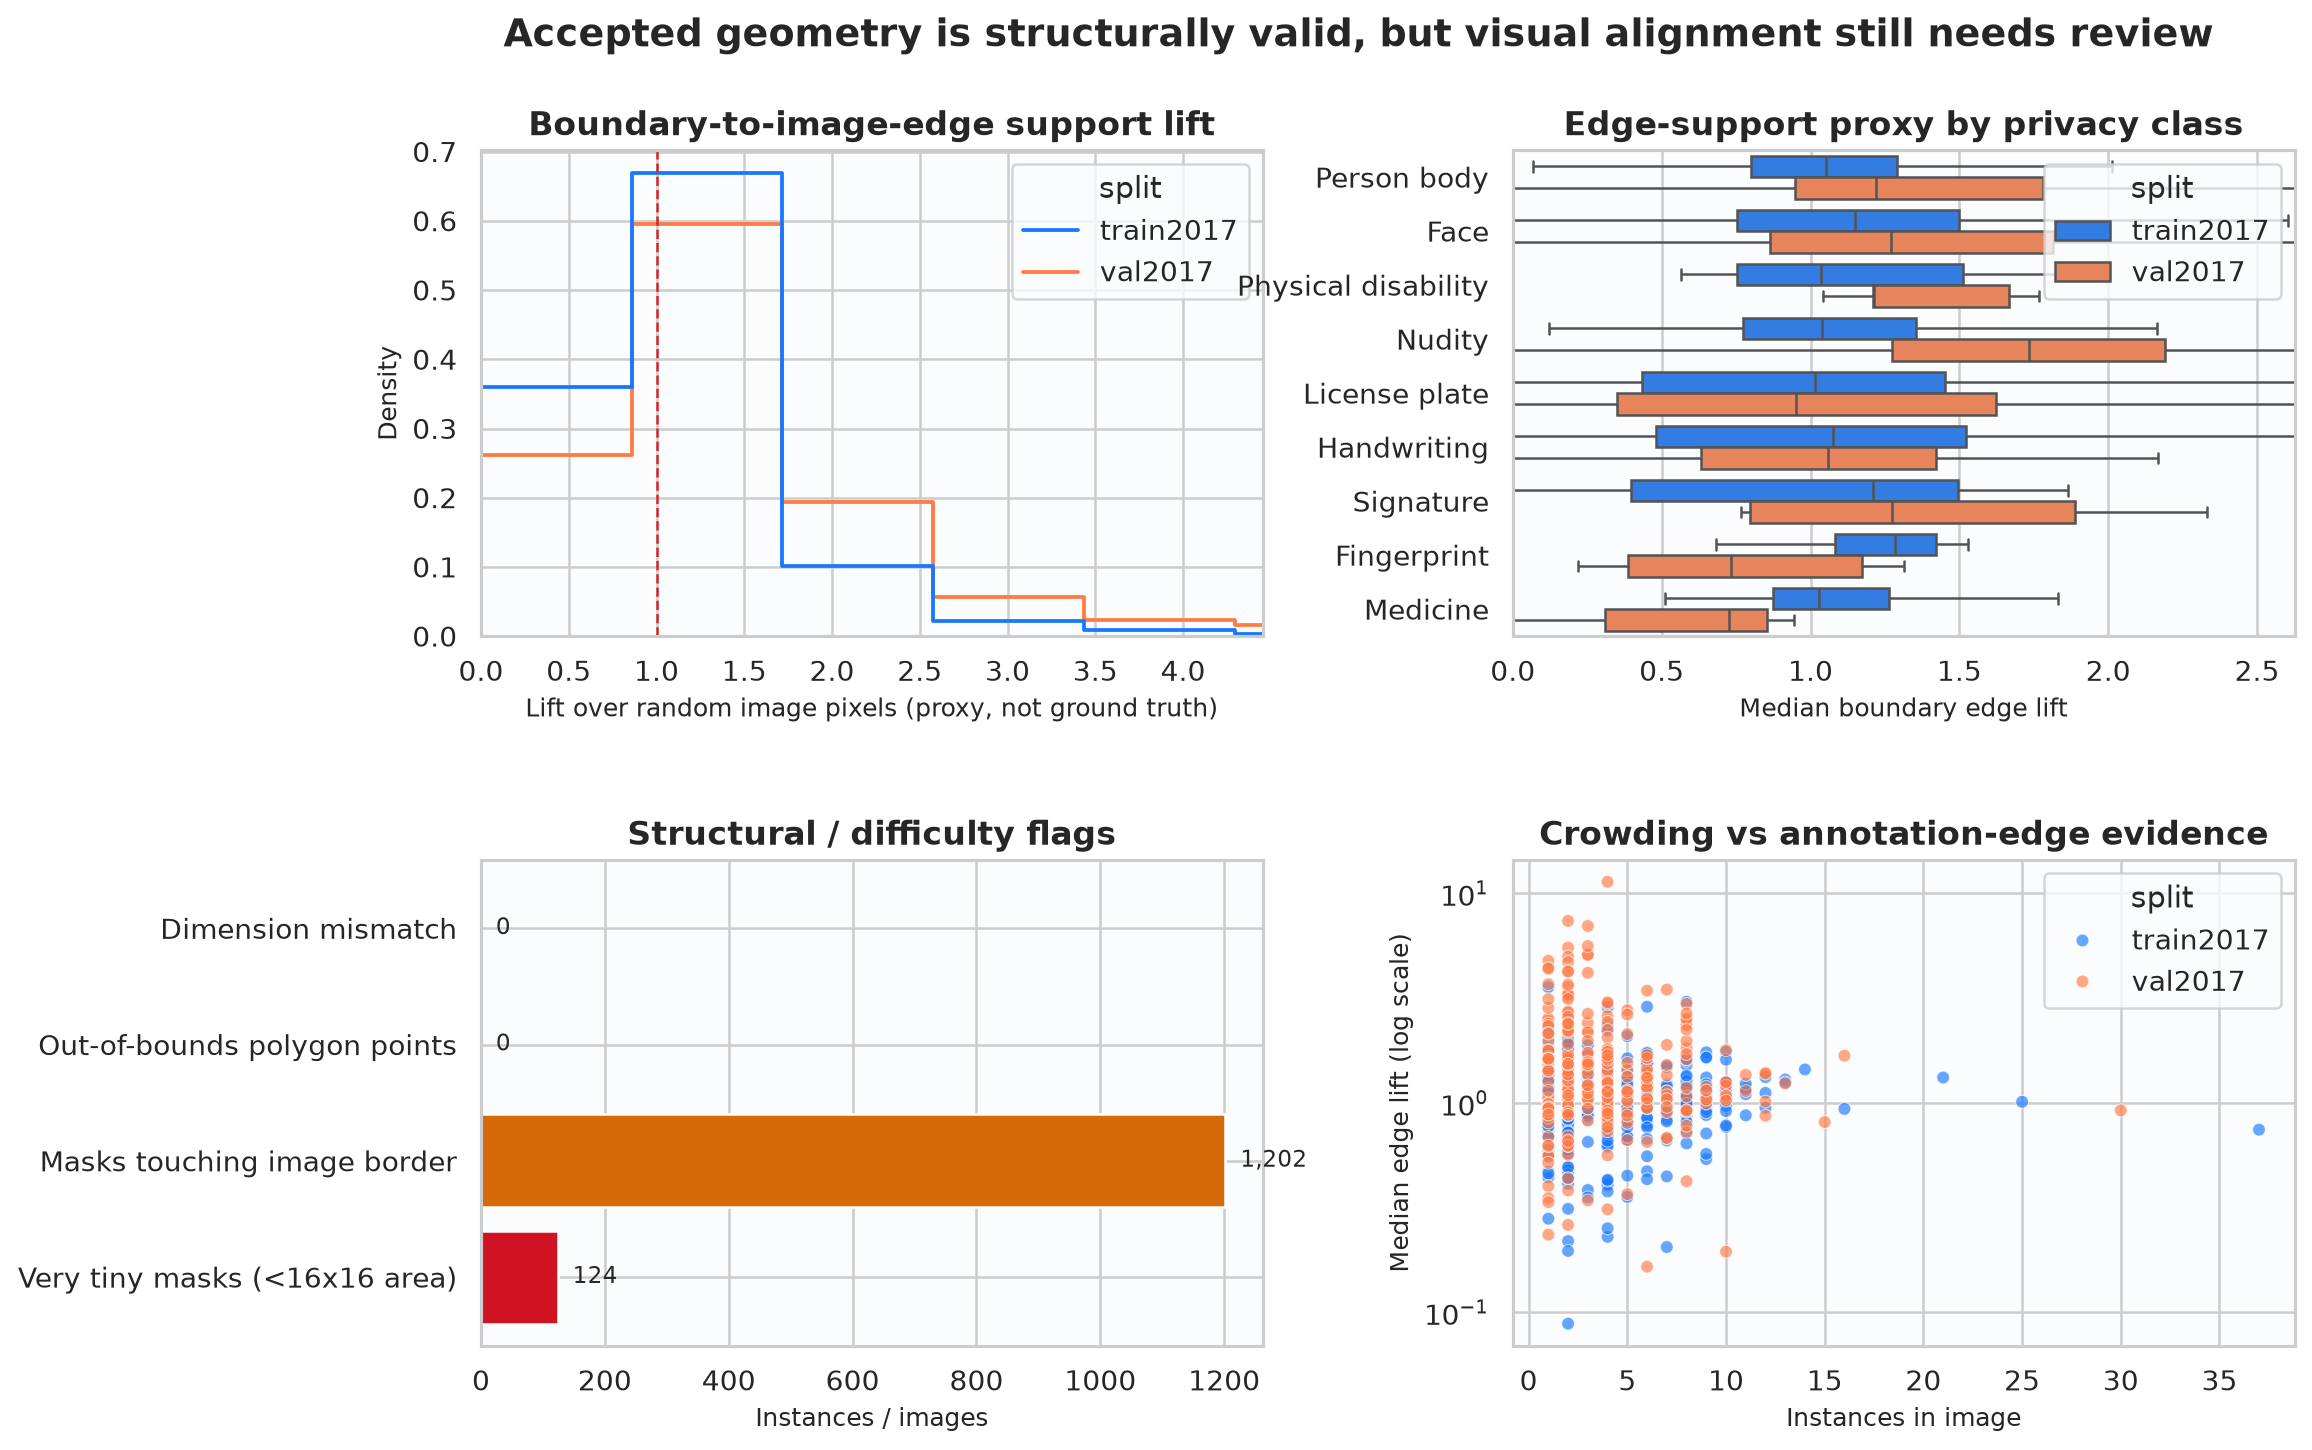

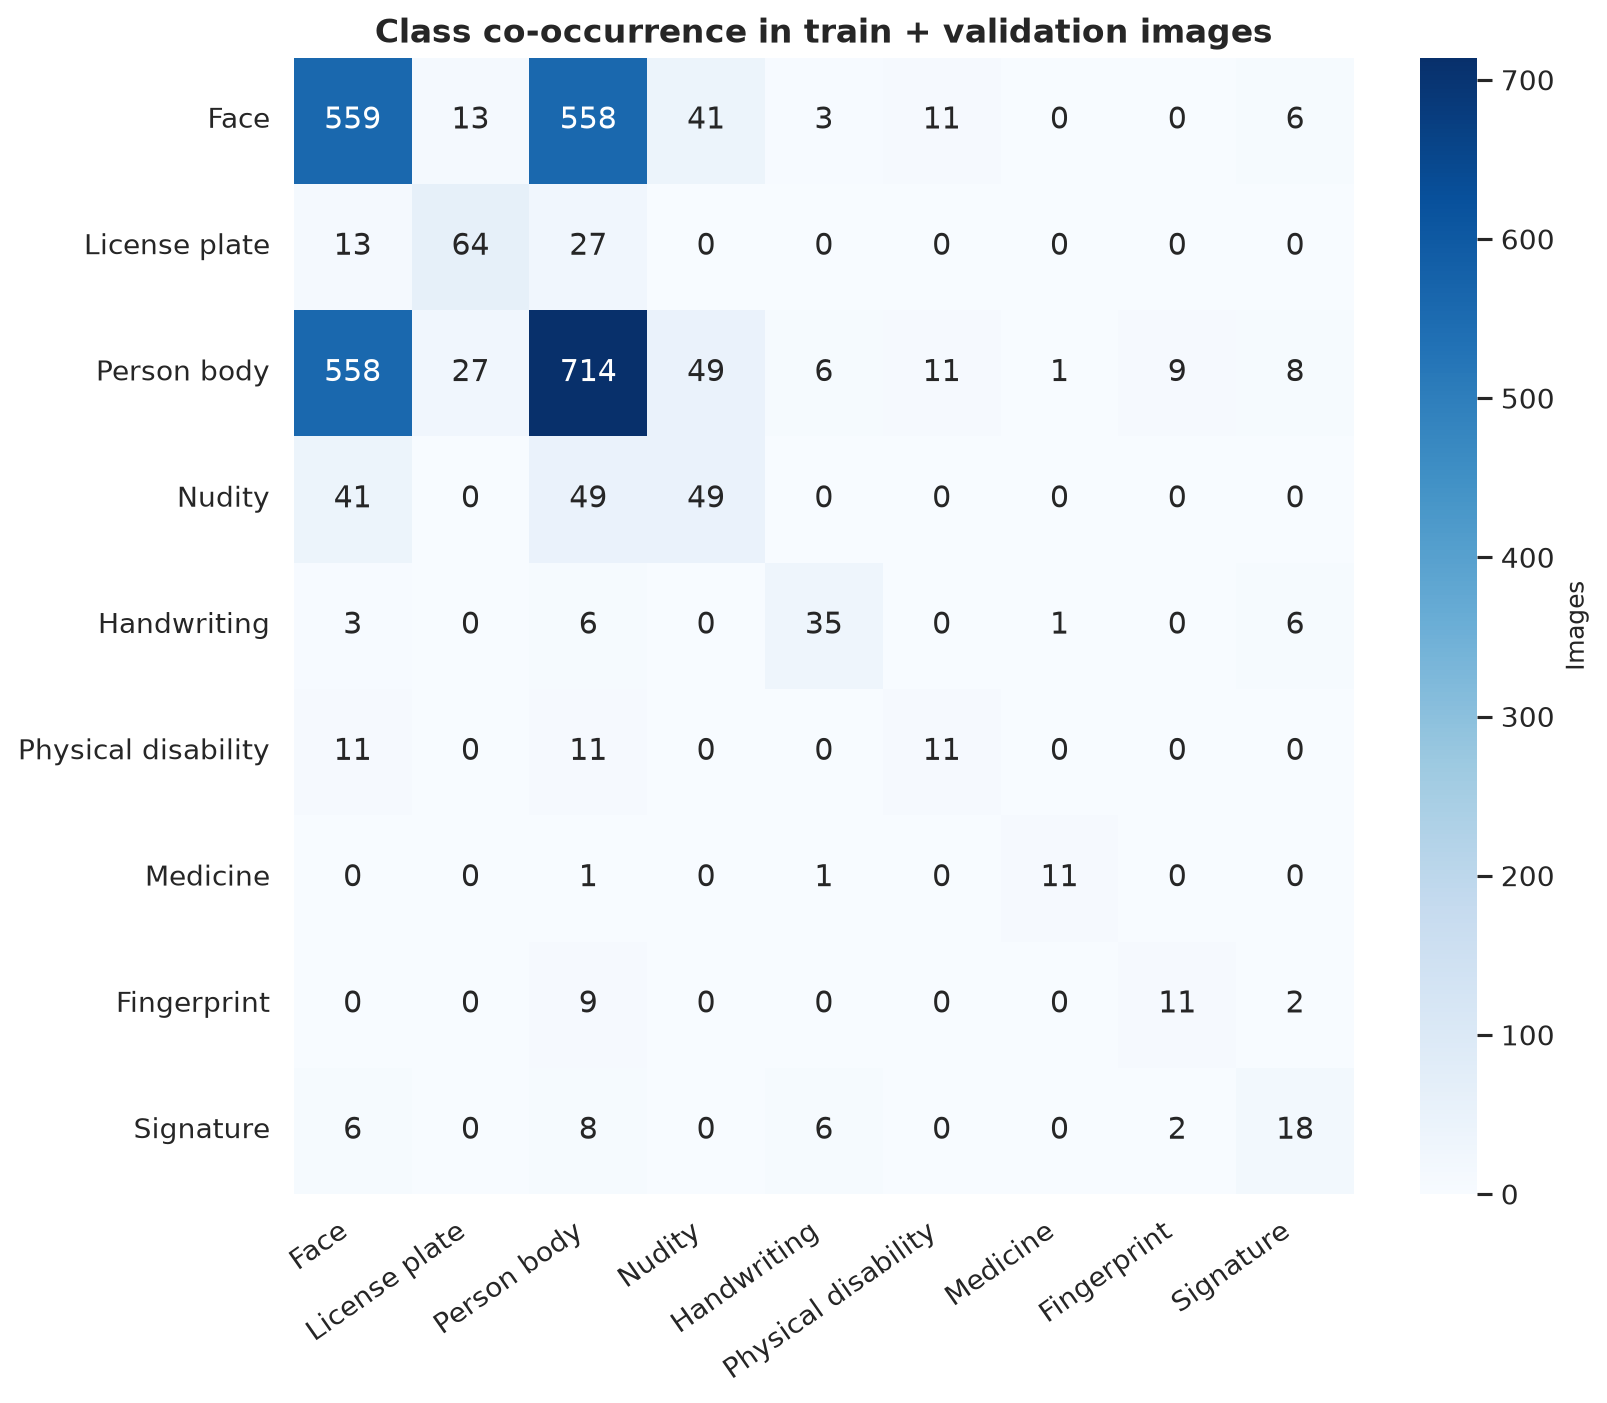

metric,train_mean,val_mean,standardized_difference_val_minus_train,ks_statistic,ks_pvalue
brightness_mean,108.5123,108.7145,0.0061,0.0507,0.7023
contrast_std,57.6456,57.7961,0.0106,0.0330,0.9825
blur_laplacian_var,1151.9320,1196.8552,0.0378,0.0613,0.4651
entropy_bits,7.2515,7.1765,-0.1147,0.0815,0.1596
edge_density,0.1316,0.1260,-0.0812,0.0803,0.1710
megapixels,7.5663,7.3903,-0.0277,0.0600,0.4938
instance_count,4.3733,4.0476,-0.0978,0.0510,0.6964
annotation_edge_lift_median,1.0752,1.5824,0.5507,0.2631,0.0000
class_distribution_jensen_shannon,0.0000,0.0853,nan,nan,nan


In [5]:
for name in ['04_image_quality_shift.png', '05_annotation_quality.png', '06_class_cooccurrence.png']:
    display(Image(filename=str(AUDIT_DIR / name), width=1100))
shift = pd.read_csv(AUDIT_DIR / 'train_validation_shift.csv')
display(shift.style.format(precision=4).hide(axis='index'))

## Manual ground-truth inspection

The first grid is stratified: one median edge-lift example per class and split. At least 14 of 18 are clearly mismatched, three are plausibly aligned, and one is uncertain. The second grid contains low edge-support cases selected for review. Sensitive nudity regions are dark-filled in these previews.

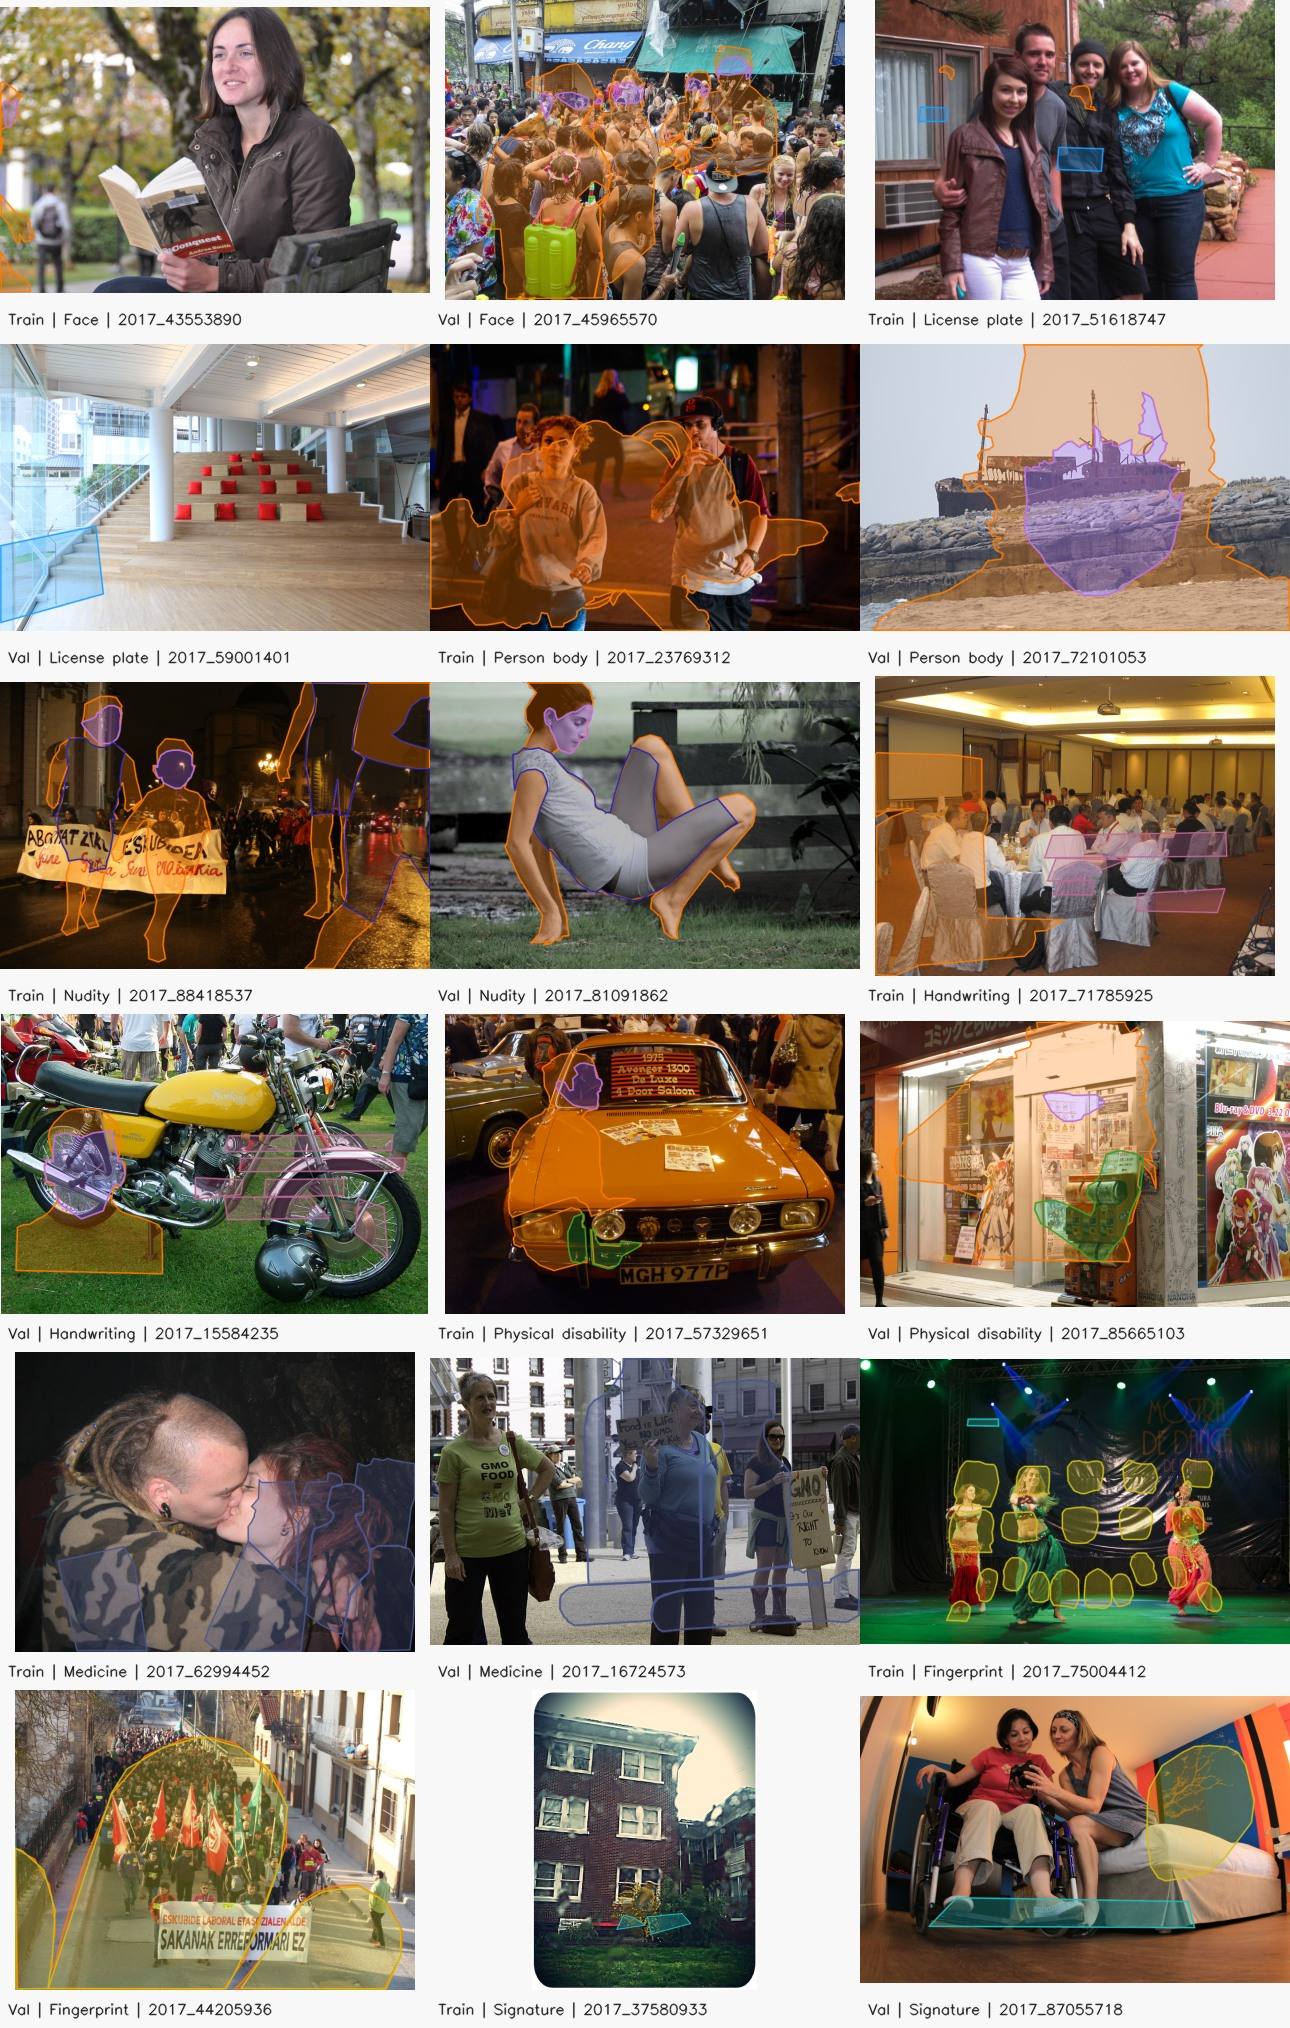

review_result,clearly_mismatched,plausibly_aligned,uncertain
focus_class,,,
Face,1,1,0
Fingerprint,2,0,0
Handwriting,2,0,0
License plate,2,0,0
Medicine,2,0,0
Nudity,0,1,1
Person body,1,1,0
Physical disability,2,0,0
Signature,2,0,0


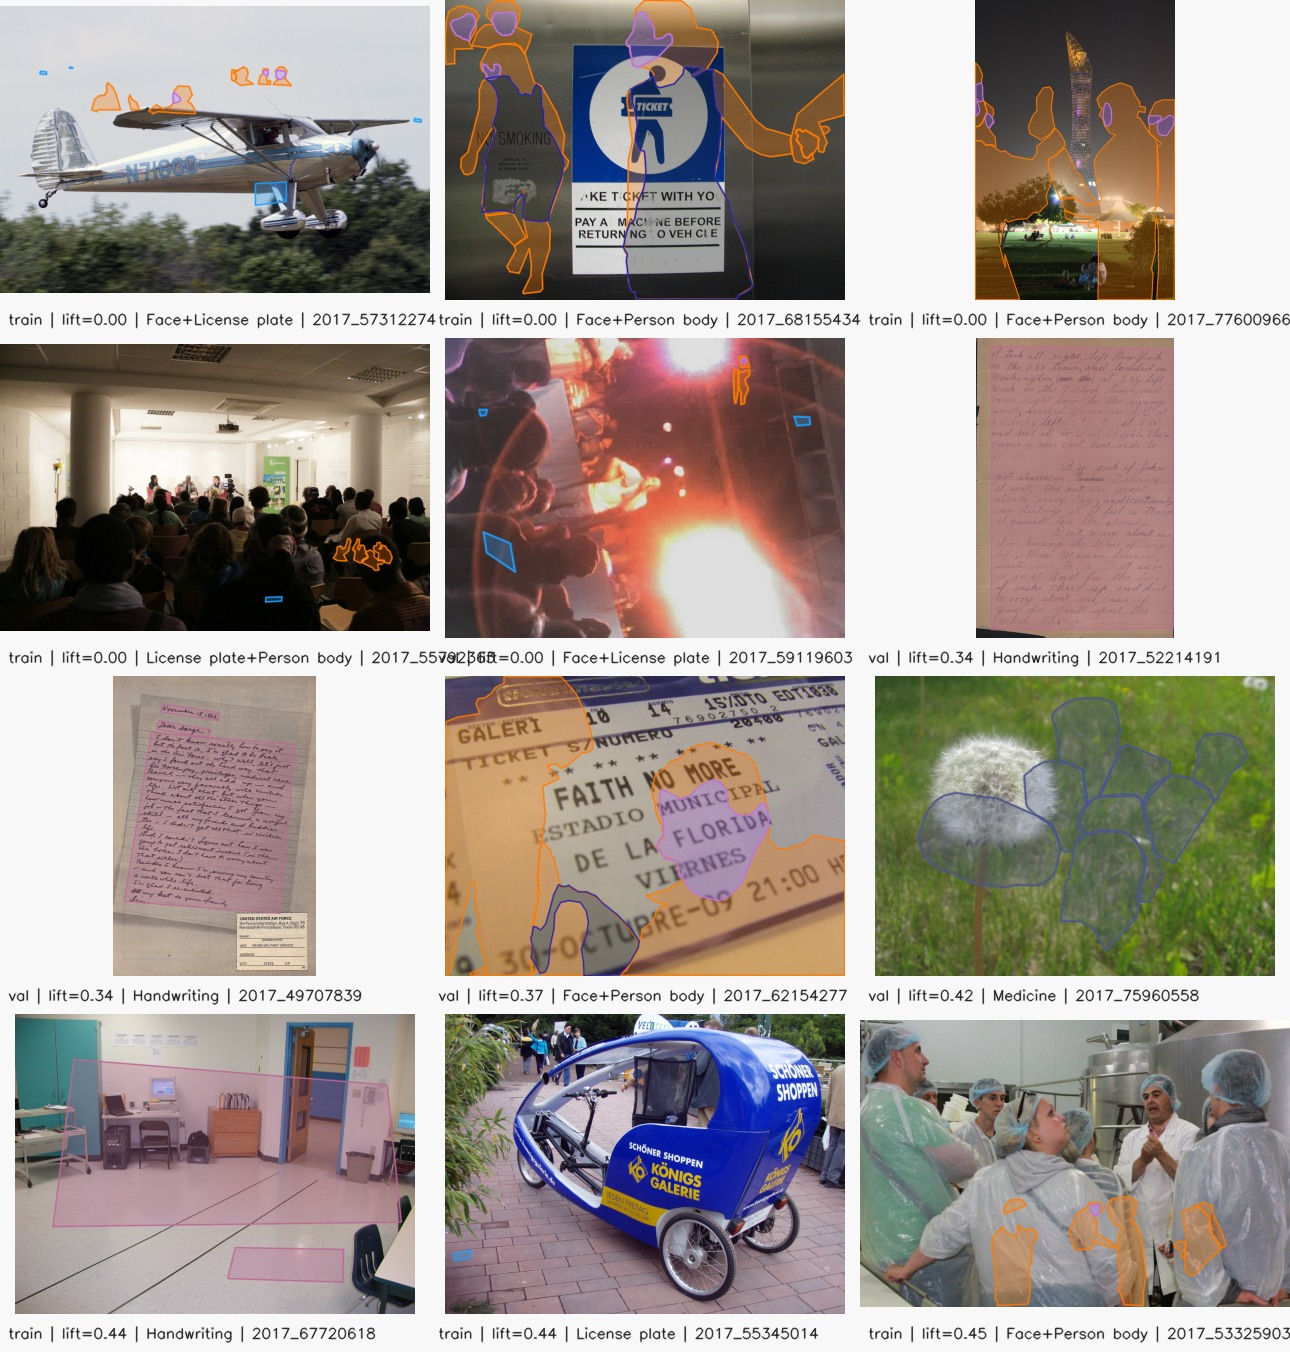

In [6]:
display(Image(filename=str(AUDIT_DIR / '09_representative_ground_truth_grid.jpg'), width=1200))
manual_review = pd.read_csv(AUDIT_DIR / 'manual_visual_review.csv', dtype={'image_id': str})
display(manual_review.groupby(['focus_class', 'review_result']).size().unstack(fill_value=0))
display(Image(filename=str(AUDIT_DIR / '10_low_edge_support_review_grid.jpg'), width=1200))

## Model diagnosis

The model code and metric path are capable of learning an eight-image fixed subset. On the contaminated 501-image training set, however, the final checkpoint has only 0.0187 mask mAP; validation is another roughly 73 times lower. The low train score indicates contradictory/noisy supervision and recipe underfit at scale, while the larger train-validation gap shows additional generalization failure.

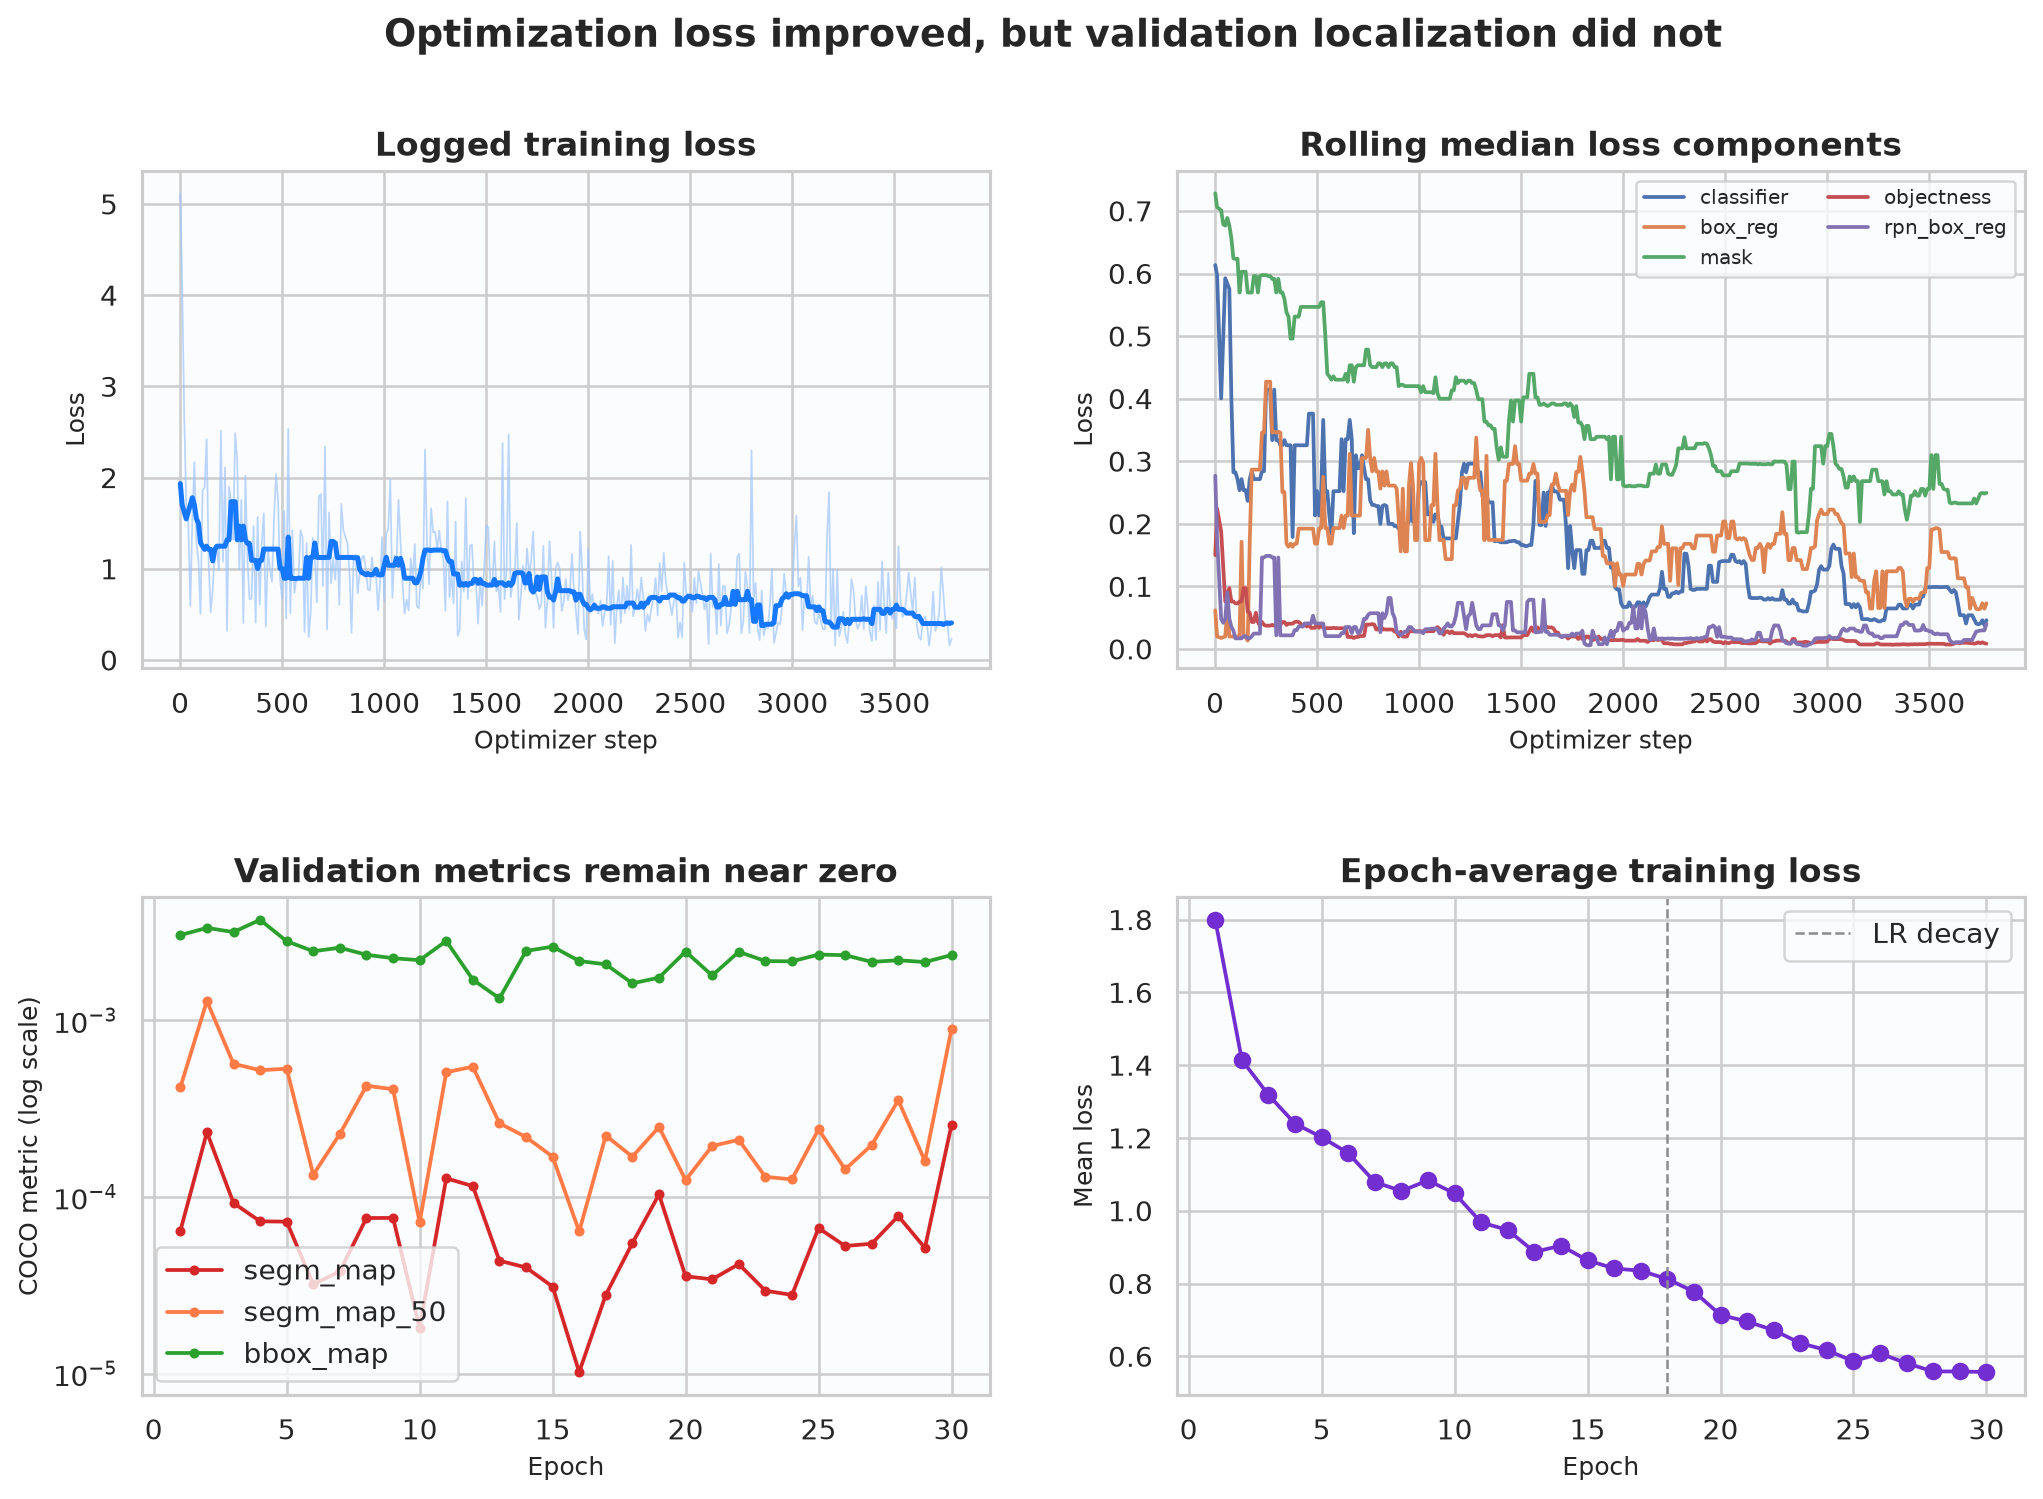

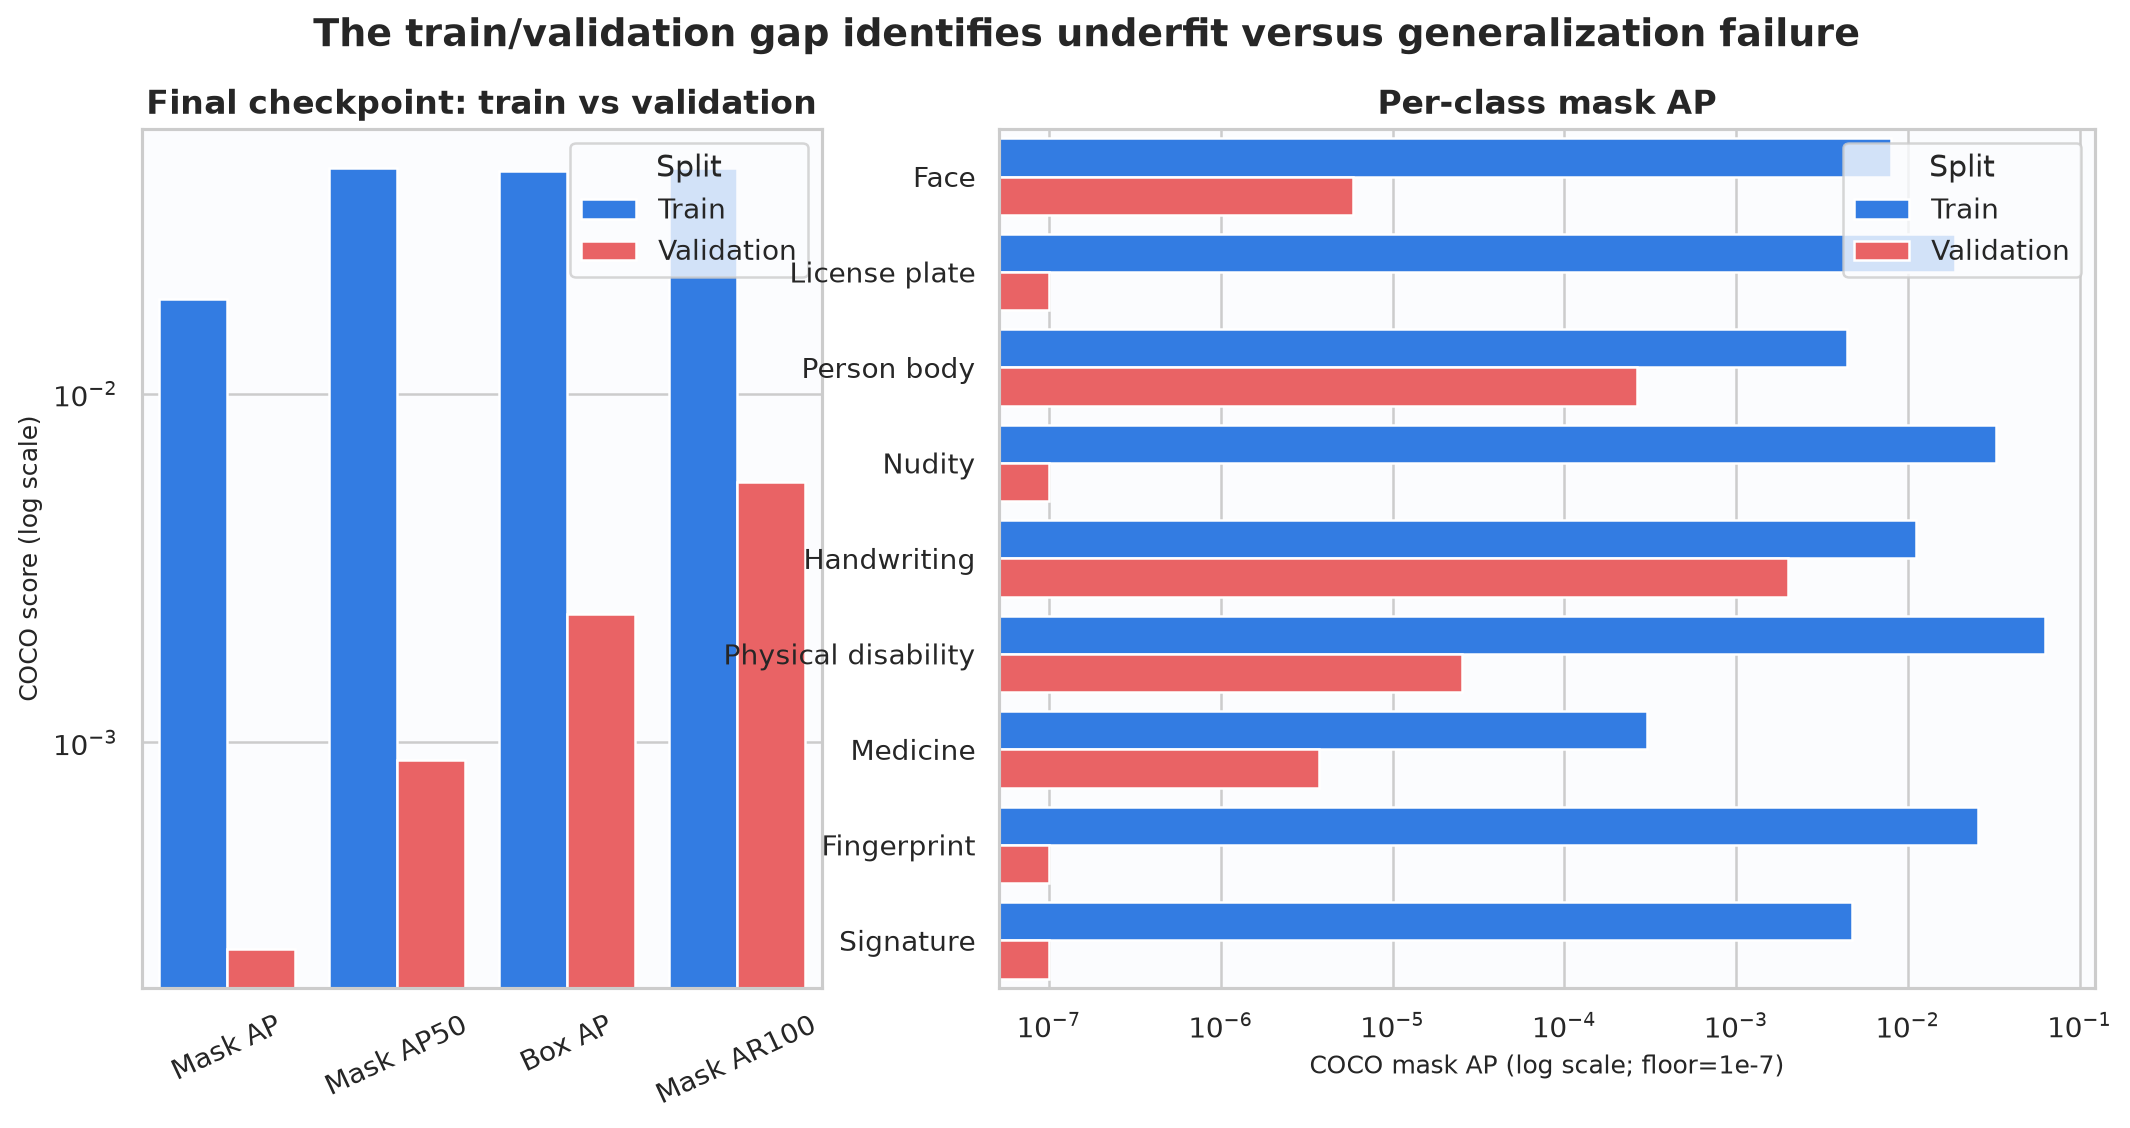

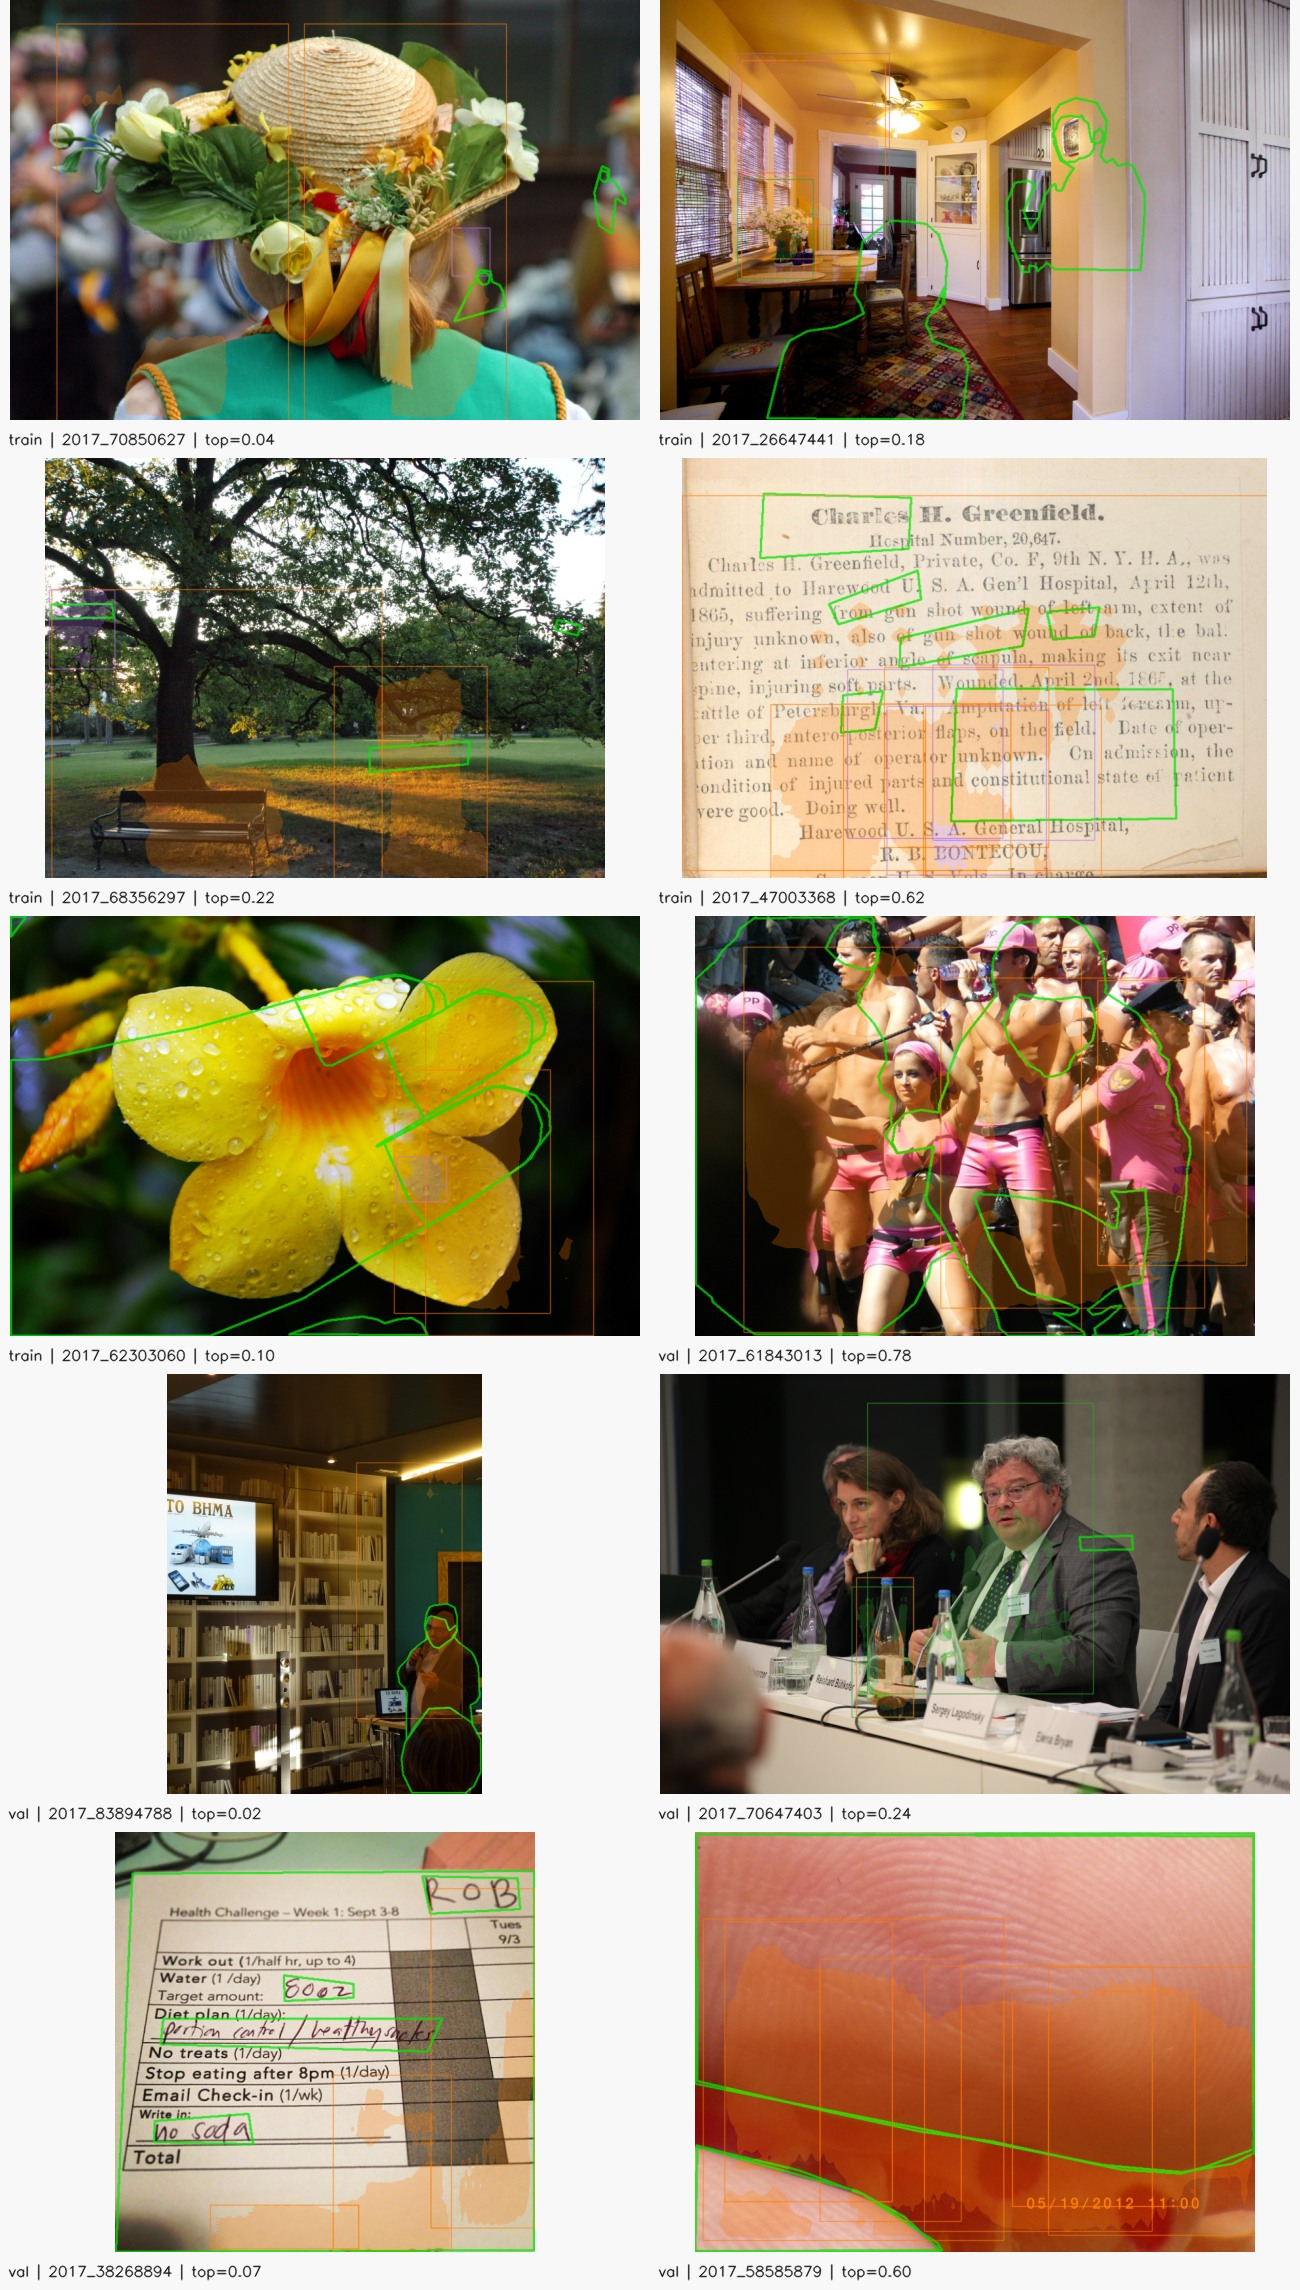

In [7]:
display(Image(filename=str(AUDIT_DIR / '07_training_curves.png'), width=1100))
display(Image(filename=str(AUDIT_DIR / '08_model_train_vs_validation.png'), width=1100))
display(Image(filename=str(AUDIT_DIR / '11_final_model_predictions_grid.jpg'), width=1100))

## Decision and next experiment

1. **Stop using the current processed records and checkpoint for scientific claims.** Preserve them only as root-cause evidence.
2. **Download the separate official Visual Redactions image archives** (15.467 GiB compressed total), extract into an isolated directory, and validate archive integrity.
3. **Rebuild records from the Visual Redactions images and masks from the same release.** Require decoded dimensions, a stratified overlay review, weak-metadata/content consistency checks, and zero cross-split duplicates. Aspect ratio alone is no longer an acceptance criterion.
4. **Create a manually approved benchmark before a full run.** Review at least 25 images per common class and every available image for classes with fewer than 25 examples.
5. **Retrain Mask R-CNN as the reproducible baseline first.** Run a one-image, eight-image, and 32-image overfit ladder, then a 5-epoch uniform-sampling baseline and balanced-sampling ablation.
6. **Only after the repaired baseline learns, compare architectures.** Mask2Former is a valid instance-segmentation comparison, not a data repair. Use specialist branches for faces/persons, OCR/text, and documents; use SAM 2 only to refine detector/OCR prompts.
7. **Do not use the local VPD videos as VPD-100K image training data.** The local repository has 2,462 videos and no verified 100K-image annotation package.